# 04 · Linear regression model

**Input:** `data/interim/rdu_hourly_features.csv` (from `03`)
**Output:** `data/processed/rdu_model_samples.csv.gz` (model matrix X and target y), backtest scores, and the 336-hour forecast for Sep 17–30, 2026.

| Section | Content |
|---|---|
| 1 | Build the model matrix X (forecast start × lead) |
| 2 | Backtest framework and baselines |
| 3 | Linear regression: feature sets and interactions |
| 4 | Validation window and final forecast |

## 1. Build the model matrix X

In [2]:
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
FEATURES_FILE = PROJECT_ROOT / "data" / "interim" / "rdu_hourly_features.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SAMPLES_FILE = PROCESSED_DIR / "rdu_model_samples.csv.gz"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

NY = ZoneInfo("America/New_York")
FORECAST_START = pd.Timestamp("2026-09-17", tz=NY)
HORIZON = 14 * 24  # 336 hourly leads


def save_fig(fig, name):
    """Save a figure to reports/figures for the slides and write-up."""
    fig.savefig(FIG_DIR / f"04_{name}.png", dpi=150, bbox_inches="tight")


table = pd.read_csv(FEATURES_FILE, index_col="hour_utc", parse_dates=["hour_utc"])
table["hour_local"] = pd.to_datetime(table["hour_local"], utc=True).dt.tz_convert(NY)

CALENDAR_FEATURES = [c for c in table.columns if c.startswith(("doy_", "hour_sin", "hour_cos"))]
STATE_FEATURES = ["anom_now", "anom_24h", "anom_7d", "anom_30d",
                  "dewpoint_depression", "pressure_change_24h", "cloud_cover_octas"]
checks = {
    "continuous hourly index (positions = hours)": table.index.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all(),
    "336 forecast hours at the end": table["partition"].iloc[-HORIZON:].eq("forecast").all(),
    "all expected feature columns present": set(CALENDAR_FEATURES + STATE_FEATURES + ["climatology"]) <= set(table.columns),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), "Unexpected feature table - rerun 03 first."
print(f"Loaded {FEATURES_FILE.relative_to(PROJECT_ROOT)}: {table.shape[0]:,} hours x {table.shape[1]} columns; "
      f"{len(CALENDAR_FEATURES)} calendar + 1 climatology + {len(STATE_FEATURES)} state features")

,passed
continuous hourly index (positions = hours),True
336 forecast hours at the end,True
all expected feature columns present,True


Loaded data/interim/rdu_hourly_features.csv: 102,983 hours x 28 columns; 12 calendar + 1 climatology + 7 state features


### 1.1 One row per (forecast start, lead)

A forecast is issued from an 11pm row and covers the next 336 hours. Each sample pairs:

- the **state at the forecast start** (`anom_now`, `anom_24h`, …, taken from the start row), and
- the **calendar features and climatology of the target hour** (taken from the target row),

with `lead_hours` = hours between the two, and the temperature at the target hour as y. Forecast starts are the 11pm rows of July–November, 2016–2026. `persistence` (the same clock hour on the last observed day) is kept for the baseline.

In [3]:
ORIGIN_HOUR = 23  # forecasts are issued from the 11pm row; lead 1 = 12am the next day
local = table["hour_local"]
is_origin = (
    local.dt.hour.eq(ORIGIN_HOUR)
    & local.dt.month.between(7, 11)
    & local.dt.year.ge(2016)
    & table["partition"].ne("forecast")
)
origins = table.index[is_origin]


def build_samples(table, origins, horizon=HORIZON):
    """One row per (forecast start, lead): state from the start row, calendar + climatology from the target row."""
    origin_pos = np.repeat(table.index.get_indexer(origins), horizon)
    lead = np.tile(np.arange(1, horizon + 1), len(origins))
    target_pos = origin_pos + lead  # the index is a continuous hourly grid, so +lead positions = +lead hours
    keep = target_pos < len(table)
    origin_pos, lead, target_pos = origin_pos[keep], lead[keep], target_pos[keep]

    column = lambda name, pos: table[name].to_numpy()[pos]
    samples = pd.DataFrame({
        "origin_utc": table.index[origin_pos],
        "target_utc": table.index[target_pos],
        "lead_hours": lead,
        "temperature": column("temperature", target_pos),
        "climatology": column("climatology", target_pos),
        **{c: column(c, target_pos) for c in CALENDAR_FEATURES + ["years_since_2015"]},
        **{c: column(c, origin_pos) for c in STATE_FEATURES},
        # Persistence baseline: same clock hour on the last observed day (the 24 h ending at the start row)
        "persistence": column("temperature", target_pos - 24 * np.ceil(lead / 24).astype(int)),
    })
    samples.insert(1, "origin_year", table.loc[samples["origin_utc"], "hour_local"].dt.year.to_numpy())
    return samples


samples = build_samples(table, origins)
print(f"Forecast starts: {len(origins):,} (11pm, Jul-Nov, 2016-2026)  ->  samples: {len(samples):,} rows")
display(samples.groupby("origin_year").agg(starts=("origin_utc", "nunique"), rows=("lead_hours", "size"),
                                           targets_known=("temperature", lambda s: int(s.notna().sum()))).T)

Forecast starts: 1,608 (11pm, Jul-Nov, 2016-2026)  ->  samples: 540,288 rows


origin_year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
starts,153,153,153,153,153,153,153,153,153,153,78
rows,51408,51408,51408,51408,51408,51408,51408,51408,51408,51408,26208
targets_known,51377,51408,51380,51408,51408,51408,51408,51408,51408,49910,23632


### 1.2 Decay interactions

On its own, a linear model cannot make the effect of the starting anomaly fade with the lead time. Each state is therefore multiplied by decay weights exp(−lead / τ) with fixed time scales: τ = 6, 24, 72 and 240 h for the anomaly states, and τ = 6 and 24 h for the weather states, which only matter during the first day (`03`, Section 4.1). The regression chooses how much of each time scale to use, which gives a flexible, data-driven decay curve.

Decay features: 16 anomaly x decay, 6 weather x decay


lead_hours  temperature  climatology  anom_now  anom_now_x_decay6  anom_now_x_decay24  \
start_local               target_local                                                                                                       
2025-09-16 23:00:00-04:00 2025-09-17 00:00:00-04:00           1         17.2       19.952    -3.205             -2.713              -3.074   
                          2025-09-17 23:00:00-04:00          24         18.3       20.246    -3.205             -0.059              -1.179   
                          2025-09-25 14:00:00-04:00         207         29.4       26.396    -3.205             -0.000              -0.001   

                                                     anom_now_x_decay72  anom_now_x_decay240  persistence  
start_local               target_local                                                                     
2025-09-16 23:00:00-04:00 2025-09-17 00:00:00-04:00              -3.160               -3.191         19.4  
                          2025-09-17 23:00:00-04:00              -2.296               -2.900         17.2  
                          2025-09-25 14:00:00-04:00              -0.181               -1.353         21.7

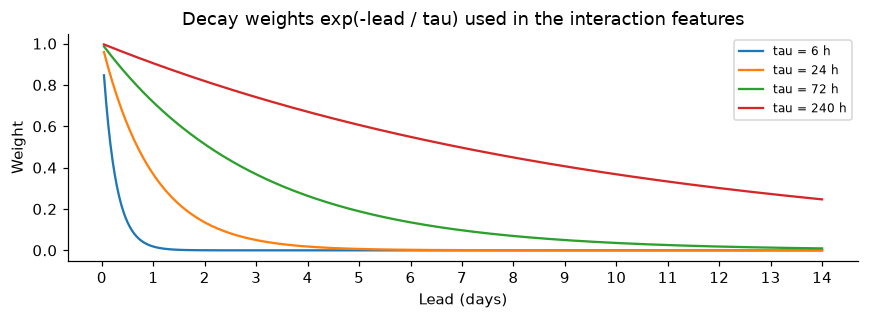

In [4]:
# Decay interactions: state x exp(-lead / tau), so a linear model can let each state fade with the lead time
DECAY_TAUS = {"anomaly": [6, 24, 72, 240], "weather": [6, 24]}  # hours, fixed in advance
ANOMALY_STATES = ["anom_now", "anom_24h", "anom_7d", "anom_30d"]
WEATHER_STATES = ["dewpoint_depression", "pressure_change_24h", "cloud_cover_octas"]


def add_decay_features(samples):
    decayed = {}
    for states, taus in [(ANOMALY_STATES, DECAY_TAUS["anomaly"]), (WEATHER_STATES, DECAY_TAUS["weather"])]:
        for tau in taus:
            weight = np.exp(-samples["lead_hours"] / tau)
            for state in states:
                decayed[f"{state}_x_decay{tau}"] = samples[state] * weight
    return pd.concat([samples, pd.DataFrame(decayed, index=samples.index)], axis=1)


samples = add_decay_features(samples)
ANOMALY_DECAY_FEATURES = [c for c in samples.columns if c.startswith("anom_") and "_x_decay" in c]
WEATHER_DECAY_FEATURES = [c for c in samples.columns if c.startswith(tuple(WEATHER_STATES)) and "_x_decay" in c]
print(f"Decay features: {len(ANOMALY_DECAY_FEATURES)} anomaly x decay, {len(WEATHER_DECAY_FEATURES)} weather x decay")

# Example: one forecast issued at 11pm Sep 16, 2025: leads 1 h, 24 h and 207 h (2pm Sep 25)
example_origin = table.index[local.eq(pd.Timestamp("2025-09-16 23:00", tz=NY))][0]
example = samples[(samples["origin_utc"] == example_origin) & samples["lead_hours"].isin([1, 24, 207])]
display(example.assign(start_local=example["origin_utc"].dt.tz_convert(NY),
                       target_local=example["target_utc"].dt.tz_convert(NY)).set_index(["start_local", "target_local"])[
    ["lead_hours", "temperature", "climatology", "anom_now", "anom_now_x_decay6", "anom_now_x_decay24",
     "anom_now_x_decay72", "anom_now_x_decay240", "persistence"]].round(3))

fig, ax = plt.subplots(figsize=(8, 3))
lead = np.arange(1, HORIZON + 1)
for tau in DECAY_TAUS["anomaly"]:
    ax.plot(lead / 24, np.exp(-lead / tau), label=f"tau = {tau} h")
ax.set(title="Decay weights exp(-lead / tau) used in the interaction features", xlabel="Lead (days)", ylabel="Weight")
ax.set_xticks(range(15))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "decay_weights")
plt.show()

### 1.3 Export X

The full sample table (identifiers, target, all candidate features and the persistence baseline) is saved compressed to `data/processed/`. Writing takes about 20–30 seconds.

In [5]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
numeric_columns = samples.select_dtypes("number").columns
samples.round({c: 4 for c in numeric_columns}).to_csv(SAMPLES_FILE, index=False, compression="gzip")
print(f"Saved {SAMPLES_FILE.relative_to(PROJECT_ROOT)}: {samples.shape[0]:,} rows x {samples.shape[1]} columns "
      f"({SAMPLES_FILE.stat().st_size / 1024 ** 2:.1f} MB compressed)")

Saved data/processed/rdu_model_samples.csv.gz: 540,288 rows x 49 columns (38.2 MB compressed)


## 2. Backtest framework and baselines

**Rolling yearly backtest.** For each test year 2017–2025, every model is fitted on samples whose forecast starts lie in *earlier* years (2016 … year − 1) and then predicts the test year. A model is never trained on the year it is scored on, or on anything later. (2016 is not tested because there is no earlier year to train on; 2015 has no past-only climatology.)

**Two evaluation sets:**

1. **Sep 17 starts:** the start that matches the real task (11pm Sep 16 → Sep 17–30), one window per test year, 9 in total.
2. **Season starts:** all forecasts whose first day falls between Aug 15 and Oct 15, about 550 windows. Same season and same rules, but far more windows, so differences between models are much less a matter of luck. Model choices are based on this set; the Sep 17 numbers are reported alongside.

Only samples with a known target and complete features are used, identical for every model. Training on earlier years only is slightly pessimistic, since a real forecaster in September would also have that year's July and August.

In [6]:
TEST_YEARS = list(range(2017, 2026))  # each year is forecast by models trained on earlier years only
EVAL_FIRST_DAYS = ("08-15", "10-15")  # evaluation windows: forecasts whose first day falls in Aug 15 - Oct 15

first_day = (samples["origin_utc"] + pd.Timedelta(hours=1)).dt.tz_convert(NY).dt.strftime("%m-%d")
samples["in_eval_season"] = first_day.between(*EVAL_FIRST_DAYS)
samples["is_sep17_start"] = first_day.eq("09-17")
usable = samples[["temperature", "climatology", "persistence", *STATE_FEATURES]].notna().all(axis=1)


def backtest(name, fit_predict):
    """For each test year: fit on all earlier years, then predict that year's evaluation windows."""
    parts = []
    for year in TEST_YEARS:
        train = samples[usable & samples["origin_year"].lt(year)]
        test = samples[usable & samples["origin_year"].eq(year) & samples["in_eval_season"]]
        parts.append(pd.DataFrame({
            "model": name, "year": year, "origin_utc": test["origin_utc"], "lead_hours": test["lead_hours"],
            "is_sep17_start": test["is_sep17_start"], "temperature": test["temperature"],
            "prediction": fit_predict(train, test),
        }))
    result = pd.concat(parts, ignore_index=True)
    result["error"] = result["temperature"] - result["prediction"]
    return result


def rmse(errors):
    return float(np.sqrt(np.mean(np.square(errors))))


def summarize(results):
    combined = pd.concat(results.values(), ignore_index=True)
    season = combined.groupby("model", sort=False)["error"]
    sep17 = combined[combined["is_sep17_start"]].groupby("model", sort=False)["error"]
    return pd.DataFrame({
        "RMSE_sep17_starts": sep17.apply(rmse),
        "RMSE_season_starts": season.apply(rmse),
        "MAE_season_starts": season.apply(lambda e: e.abs().mean()),
        "bias_season_starts": season.mean(),
    }).round(3)


def rmse_by_lead_day(results, sep17_only=False):
    combined = pd.concat(results.values(), ignore_index=True)
    if sep17_only:
        combined = combined[combined["is_sep17_start"]]
    lead_day = (combined["lead_hours"] - 1) // 24 + 1
    return combined.groupby([lead_day.rename("lead_day"), "model"], sort=False)["error"].apply(rmse).unstack()


eval_rows = samples[usable & samples["origin_year"].isin(TEST_YEARS) & samples["in_eval_season"]]
print(f"Test years: {TEST_YEARS[0]}-{TEST_YEARS[-1]} ({len(TEST_YEARS)} folds)")
print(f"Evaluation windows: {eval_rows['origin_utc'].nunique():,} forecasts starting Aug 15 - Oct 15 "
      f"({len(eval_rows):,} hourly targets), of which {eval_rows.loc[eval_rows['is_sep17_start'], 'origin_utc'].nunique()} "
      f"start on Sep 17")

Test years: 2017-2025 (9 folds)
Evaluation windows: 549 forecasts starting Aug 15 - Oct 15 (183,142 hourly targets), of which 9 start on Sep 17


### 2.1 Baselines in the same framework

- **Climatology:** the `climatology` column of the target hour (the past-only normal from `03`). It differs slightly from the smoothed hourly averages used in `02`, Section 6c.
- **Persistence:** repeat the last observed day (the 24 hours ending at the forecast start).

Neither baseline needs training; they go through the same folds and the same evaluation rows as the models.

,RMSE_sep17_starts,RMSE_season_starts,MAE_season_starts,bias_season_starts
model,,,,
climatology,3.655,3.654,2.973,0.058
persistence,4.402,4.874,3.787,-1.245


year,2017,2018,2019,2020,2021,2022,2023,2024,2025
model,,,,,,,,,
climatology,2.90,2.79,4.66,5.02,3.22,3.89,2.80,3.40,3.49
persistence,2.58,3.31,3.72,4.46,5.28,4.37,4.97,4.69,5.42


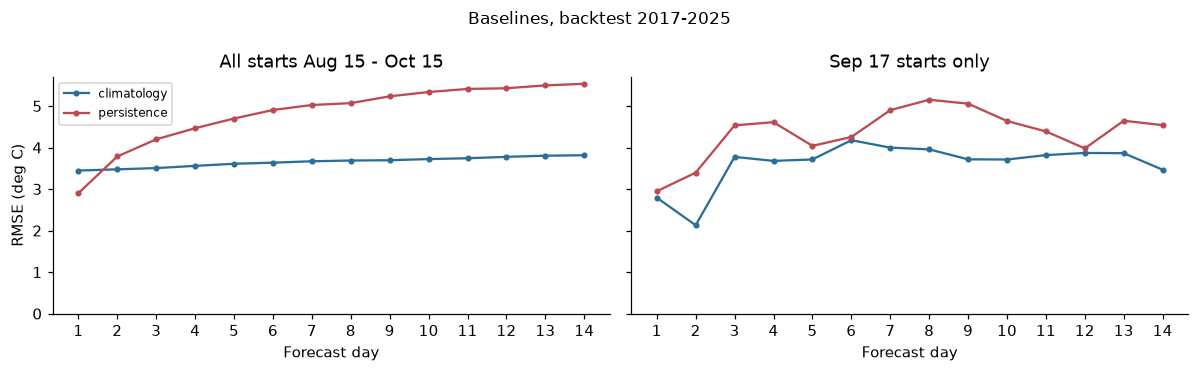

In [7]:
BASELINES = {
    "climatology": lambda train, test: test["climatology"].to_numpy(),
    "persistence": lambda train, test: test["persistence"].to_numpy(),
}
results = {name: backtest(name, fit_predict) for name, fit_predict in BASELINES.items()}
display(summarize(results))

sep17_by_year = (
    pd.concat(results.values()).query("is_sep17_start")
    .groupby(["year", "model"])["error"].apply(rmse).unstack().round(2)
)
display(sep17_by_year.T)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, sep17_only, title in [(axes[0], False, "All starts Aug 15 - Oct 15"), (axes[1], True, "Sep 17 starts only")]:
    by_day = rmse_by_lead_day(results, sep17_only)
    for (name, values), color in zip(by_day.items(), ["#2a6f97", "#bc4b51"]):
        ax.plot(values.index, values, marker="o", markersize=3, color=color, label=name)
    ax.set(title=title, xlabel="Forecast day")
    ax.set_xticks(range(1, 15))
axes[0].set(ylabel="RMSE (deg C)", ylim=(0, None))
axes[0].legend(fontsize=8)
fig.suptitle(f"Baselines, backtest {TEST_YEARS[0]}-{TEST_YEARS[-1]}", fontsize=11)
fig.tight_layout()
save_fig(fig, "baselines_by_lead_day")
plt.show()

## 3. Linear regression

**Target choice.** A first attempt (LR0) regressed the temperature itself on the calendar features, the climatology and the start state. In every fold the model re-learned its own seasonal curve from only a few seasons (a single season in the 2017 fold) and overfitted those years. The models below therefore predict the **anomaly of the target hour** (temperature − climatology), and the forecast is climatology + predicted anomaly. The seasonal and daily cycle stay with the past-only climatology; the regression only learns how the starting anomaly fades.

**No intercept.** The anomaly is zero on average by construction. An intercept would copy the average anomaly of the training years into every future forecast, which does not carry over and makes long leads worse than climatology. Without it, the forecast falls back exactly to climatology once the decay terms reach zero.

All models use scikit-learn's `LinearRegression`:

| Model | Features |
|---|---|
| LR0 | temperature target: calendar + climatology + all decay features (first attempt) |
| LR1 | anomaly target: raw start state, no decay (7) |
| LR2 | anomaly states × decay, τ = 6 / 24 / 72 h (12) |
| LR3 | LR2 + weather states × decay, τ = 6 / 24 h (18) |
| LR4 | LR3 + slow decay, τ = 240 h (22) |

In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

SHORT_DECAY = [c for c in ANOMALY_DECAY_FEATURES if not c.endswith("decay240")]  # tau = 6, 24, 72 h
SLOW_DECAY = [c for c in ANOMALY_DECAY_FEATURES if c.endswith("decay240")]       # tau = 240 h


def temperature_regression(columns):
    """First attempt: regress the temperature itself on calendar features, climatology and the start state."""
    def fit_predict(train, test):
        model = LinearRegression().fit(train[columns], train["temperature"])
        return model.predict(test[columns])
    return fit_predict


def anomaly_regression(columns):
    """Regress the target-hour anomaly (no intercept); the forecast is climatology + predicted anomaly."""
    def fit_predict(train, test):
        model = LinearRegression(fit_intercept=False).fit(train[columns], train["temperature"] - train["climatology"])
        return test["climatology"].to_numpy() + model.predict(test[columns])
    return fit_predict


MODELS = {
    "LR0 temperature target (calendar + climatology + decay)":
        (temperature_regression, CALENDAR_FEATURES + ["climatology"] + ANOMALY_DECAY_FEATURES + WEATHER_DECAY_FEATURES),
    "LR1 anomaly ~ raw start state (no decay)": (anomaly_regression, STATE_FEATURES),
    "LR2 anomaly ~ anomaly x decay (6/24/72 h)": (anomaly_regression, SHORT_DECAY),
    "LR3 + weather x decay": (anomaly_regression, SHORT_DECAY + WEATHER_DECAY_FEATURES),
    "LR4 + slow decay (240 h)": (anomaly_regression, SHORT_DECAY + SLOW_DECAY + WEATHER_DECAY_FEATURES),
}
MODEL_FEATURES = {}
for name, (make_model, columns) in MODELS.items():
    results[name] = backtest(name, make_model(columns))
    MODEL_FEATURES[name] = columns
    print(f"{name:<58} {len(columns):>3} features   season RMSE {rmse(results[name]['error']):.3f}")

LR0 temperature target (calendar + climatology + decay)     35 features   season RMSE 4.131
LR1 anomaly ~ raw start state (no decay)                     7 features   season RMSE 3.657
LR2 anomaly ~ anomaly x decay (6/24/72 h)                   12 features   season RMSE 3.565
LR3 + weather x decay                                       18 features   season RMSE 3.564
LR4 + slow decay (240 h)                                    22 features   season RMSE 3.604


### 3.1 Polynomial features experiment

`PolynomialFeatures(degree=2)` expands the 7 state features and the lead time into all squares and pairwise products (44 terms), followed by standardization and a Ridge penalty. This tests whether a generic expansion can replace the hand-designed decay terms.

In [9]:
# Experiment: PolynomialFeatures(degree=2) builds every square and pairwise product of the start state and the lead
POLY_INPUTS = STATE_FEATURES + ["lead_hours"]


def polynomial_anomaly_ridge(train, test):
    model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), StandardScaler(),
                          Ridge(alpha=1.0))
    model.fit(train[POLY_INPUTS], train["temperature"] - train["climatology"])
    return test["climatology"].to_numpy() + model.predict(test[POLY_INPUTS])


POLY_NAME = "LR5 anomaly ~ poly(2) of state & lead, ridge"
n_poly = PolynomialFeatures(degree=2, include_bias=False).fit(np.zeros((1, len(POLY_INPUTS)))).n_output_features_
results[POLY_NAME] = backtest(POLY_NAME, polynomial_anomaly_ridge)
print(f"{len(POLY_INPUTS)} inputs -> {n_poly} polynomial terms; season RMSE {rmse(results[POLY_NAME]['error']):.3f}")

8 inputs -> 44 polynomial terms; season RMSE 3.658


### 3.2 Comparison and model selection

The selected model is the linear regression with the lowest RMSE on the season starts. RMSE by forecast day shows where the gain over the baselines comes from.

,RMSE_sep17_starts,RMSE_season_starts,MAE_season_starts,bias_season_starts,vs_climatology_pct
model,,,,,
climatology,3.655,3.654,2.973,0.058,0.0
persistence,4.402,4.874,3.787,-1.245,33.4
LR0 temperature target (calendar + climatology + decay),4.091,4.131,3.221,-0.902,13.1
LR1 anomaly ~ raw start state (no decay),3.685,3.657,2.981,0.081,0.1
LR2 anomaly ~ anomaly x decay (6/24/72 h),3.661,3.565,2.877,0.031,-2.4
LR3 + weather x decay,3.644,3.564,2.878,0.059,-2.5
LR4 + slow decay (240 h),3.654,3.604,2.911,0.039,-1.4
"LR5 anomaly ~ poly(2) of state & lead, ridge",3.714,3.658,2.962,0.087,0.1


Selected linear model (lowest RMSE on the season starts): LR3 + weather x decay (18 features)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
model,,,,,,,,,,,,,,
climatology,3.45,3.47,3.51,3.56,3.61,3.64,3.67,3.69,3.69,3.72,3.74,3.78,3.80,3.82
persistence,2.90,3.78,4.20,4.47,4.70,4.90,5.02,5.07,5.23,5.34,5.41,5.43,5.50,5.54
LR1 anomaly ~ raw start state (no decay),3.08,3.25,3.39,3.51,3.60,3.66,3.72,3.75,3.77,3.80,3.83,3.87,3.91,3.93
LR3 + weather x decay,2.48,3.10,3.38,3.53,3.61,3.64,3.67,3.69,3.70,3.73,3.75,3.78,3.81,3.82


year,2017,2018,2019,2020,2021,2022,2023,2024,2025
model,,,,,,,,,
LR3 + weather x decay,3.3,2.39,4.71,4.86,3.03,3.90,2.75,3.5,3.60
climatology,2.9,2.79,4.66,5.02,3.22,3.89,2.80,3.4,3.49


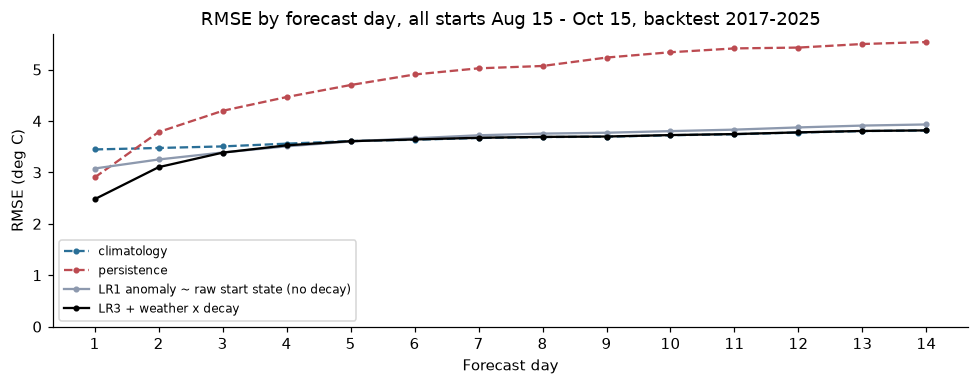

In [10]:
summary = summarize(results)
summary["vs_climatology_pct"] = (100 * (summary["RMSE_season_starts"] / summary.loc["climatology", "RMSE_season_starts"] - 1)).round(1)
display(summary)

BEST_NAME = summary.loc[list(MODEL_FEATURES), "RMSE_season_starts"].idxmin()
BEST_FEATURES = MODEL_FEATURES[BEST_NAME]
print(f"Selected linear model (lowest RMSE on the season starts): {BEST_NAME} ({len(BEST_FEATURES)} features)")

compare = ["climatology", "persistence", "LR1 anomaly ~ raw start state (no decay)", BEST_NAME]
by_day = rmse_by_lead_day({name: results[name] for name in compare})
display(by_day.T.round(2))
sep17_years = pd.concat([results[n] for n in ["climatology", BEST_NAME]]).query("is_sep17_start")
display(sep17_years.groupby(["year", "model"])["error"].apply(rmse).unstack().round(2).T)

fig, ax = plt.subplots(figsize=(9, 3.6))
styles = {"climatology": ("#2a6f97", "--"), "persistence": ("#bc4b51", "--"),
          "LR1 anomaly ~ raw start state (no decay)": ("#8d99ae", "-"), BEST_NAME: ("black", "-")}
for name, (color, line) in styles.items():
    ax.plot(by_day.index, by_day[name], color=color, linestyle=line, marker="o", markersize=3, label=name)
ax.set(title=f"RMSE by forecast day, all starts Aug 15 - Oct 15, backtest {TEST_YEARS[0]}-{TEST_YEARS[-1]}",
       xlabel="Forecast day", ylabel="RMSE (deg C)", ylim=(0, None))
ax.set_xticks(range(1, 15))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "linear_models_by_lead_day")
plt.show()